In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


In [9]:
df_index = pd.read_csv("economic_index.csv")

In [10]:
df_index.head(10)

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256
5,5,2017,7,2.50,5.6,1254
6,6,2017,6,2.50,5.5,1234
7,7,2017,5,2.25,5.5,1195
8,8,2017,4,2.25,5.5,1159
9,9,2017,3,2.25,5.6,1167


In [11]:
df_index.isnull().sum()

,0
Unnamed: 0,0
year,0
month,0
interest_rate,0
unemployment_rate,0
index_price,0


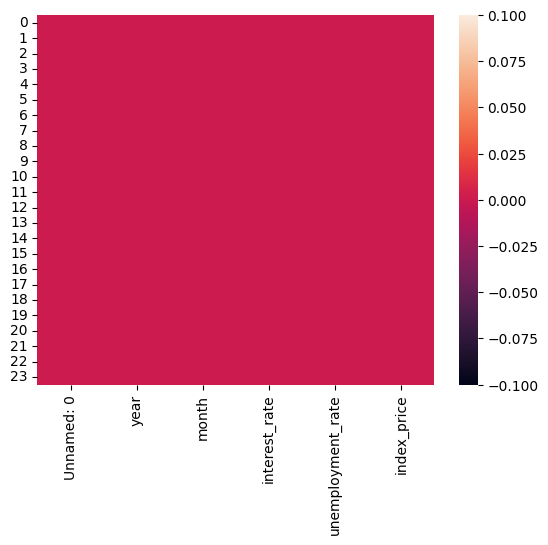

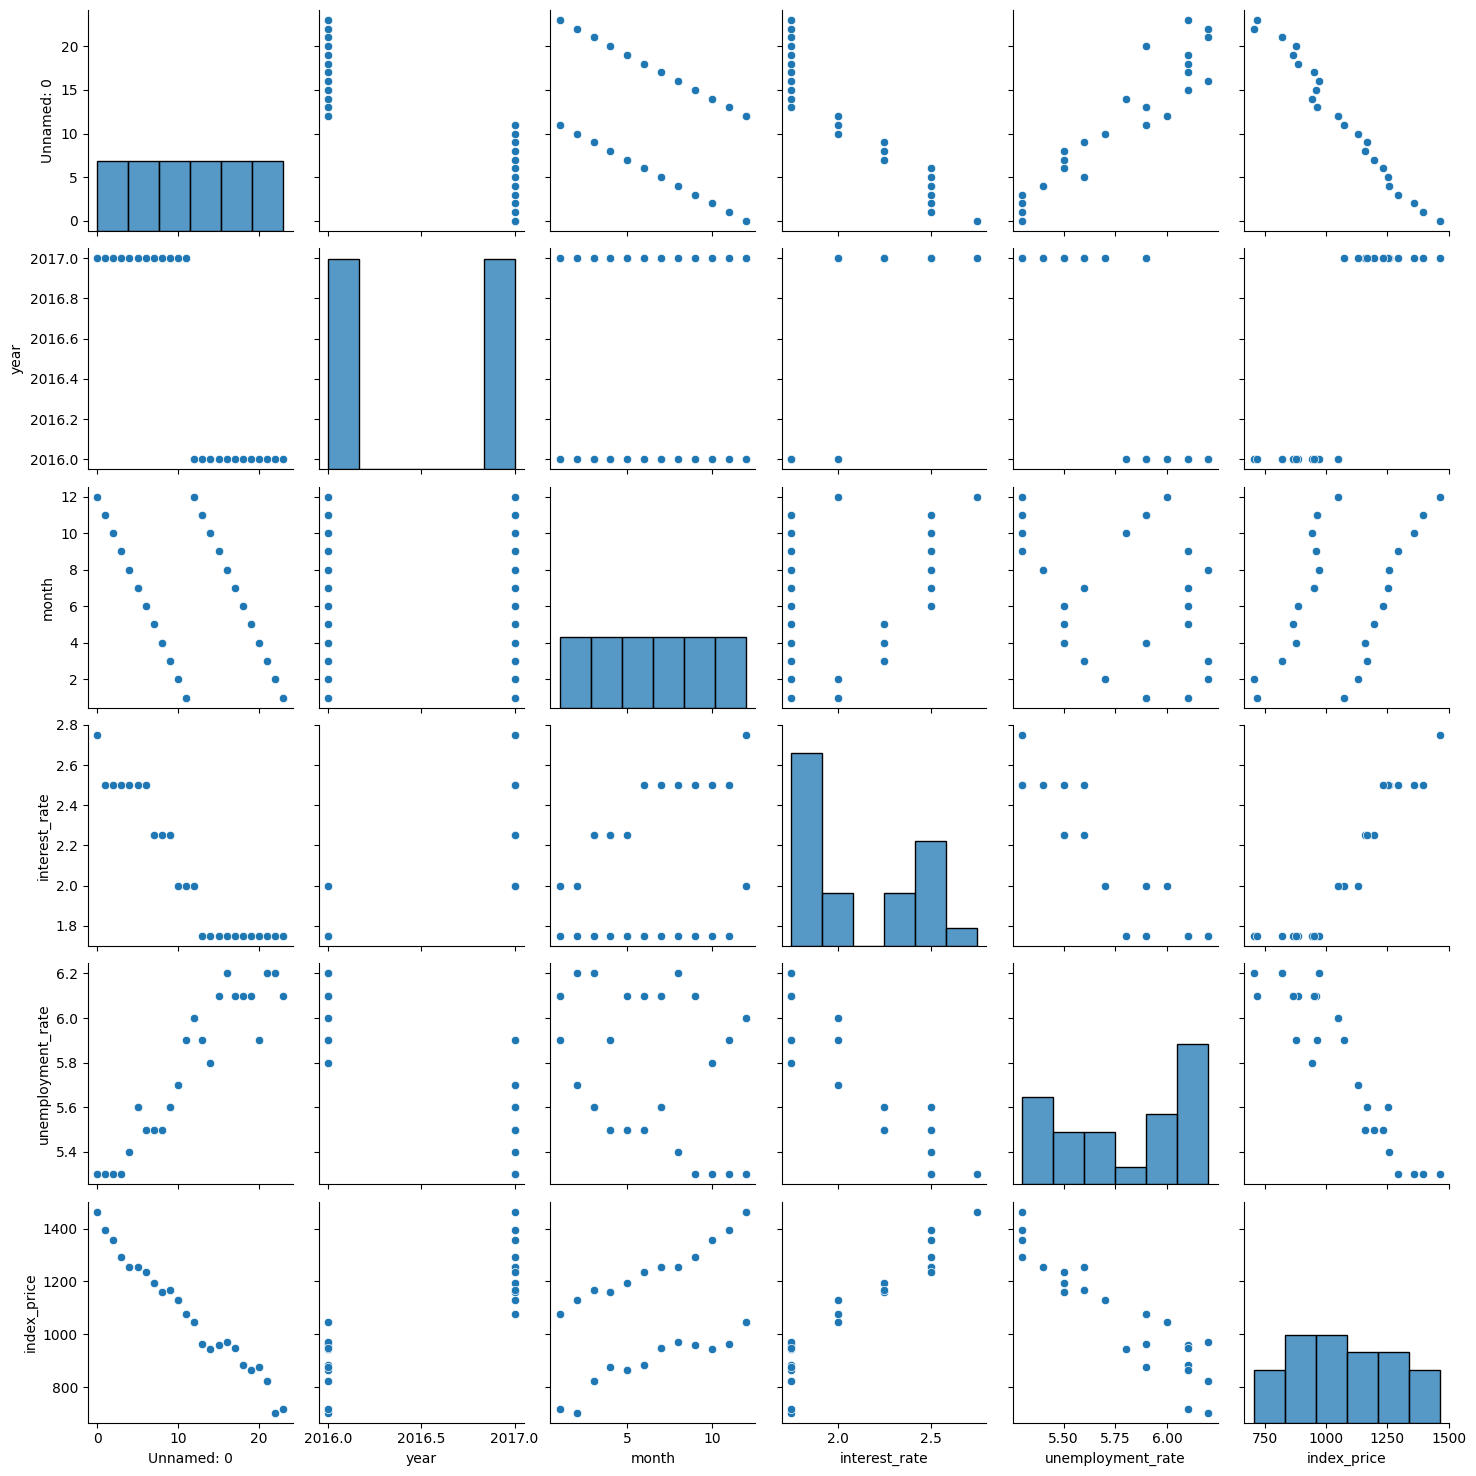

In [12]:
import seaborn as sns
sns.heatmap(df_index.isnull())
sns.pairplot(df_index)


In [13]:
df_index.corr()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
Unnamed: 0,1.000000,-8.667781e-01,-4.986939e-01,-0.934555,0.935300,-0.988246
year,-0.866778,1.000000e+00,7.884865e-14,0.882851,-0.877000,0.863232
month,-0.498694,7.884865e-14,1.000000e+00,0.339526,-0.351189,0.481287
interest_rate,-0.934555,8.828507e-01,3.395257e-01,1.000000,-0.925814,0.935793
unemployment_rate,0.935300,-8.769997e-01,-3.511891e-01,-0.925814,1.000000,-0.922338
index_price,-0.988246,8.632321e-01,4.812873e-01,0.935793,-0.922338,1.000000


In [14]:
df_index.drop(columns =["Unnamed: 0","year","month"],axis=1,inplace=True)

<Axes: >

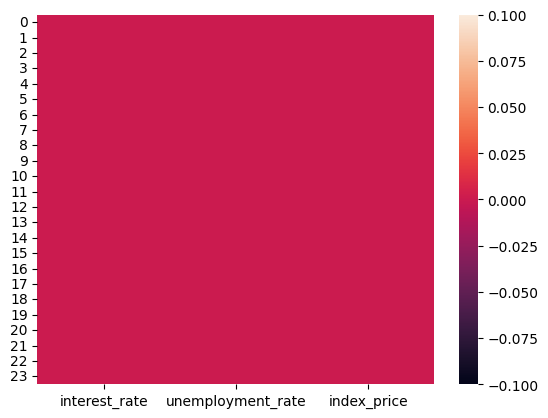

In [15]:
sns.heatmap(df_index.isnull())


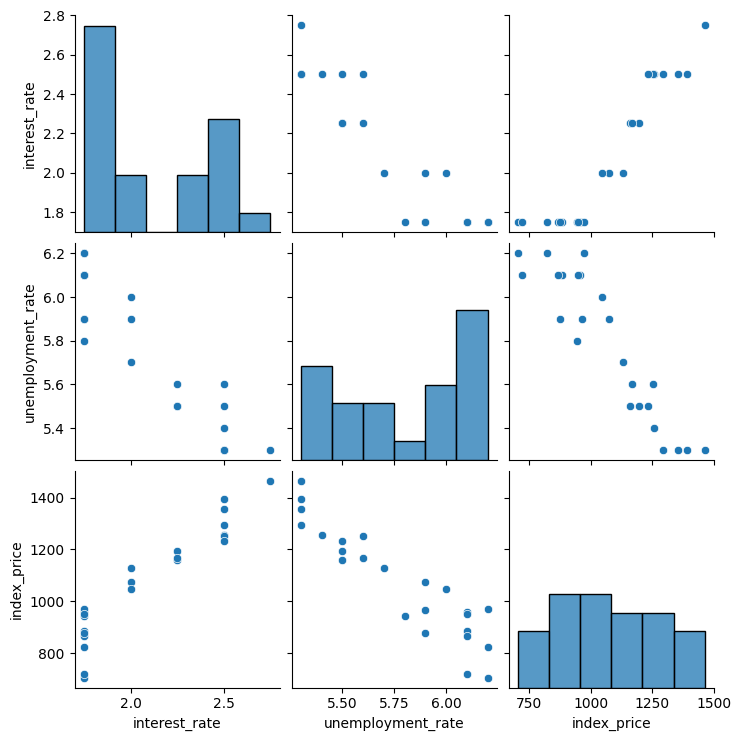

In [16]:
sns.pairplot(df_index)

Text(0, 0.5, 'unemployment_rate')

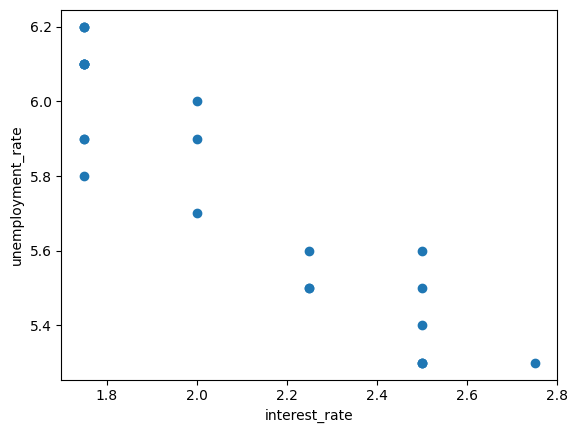

In [17]:
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'])
plt.xlabel('interest_rate')
plt.ylabel('unemployment_rate')

In [20]:
X=df_index[['interest_rate','unemployment_rate']]
y=df_index['index_price']

In [21]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [22]:
y

,index_price
0,1464
1,1394
2,1357
3,1293
4,1256
5,1254
6,1234
7,1195
8,1159
9,1167


In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [24]:
import seaborn as sns


<Axes: xlabel='interest_rate', ylabel='index_price'>

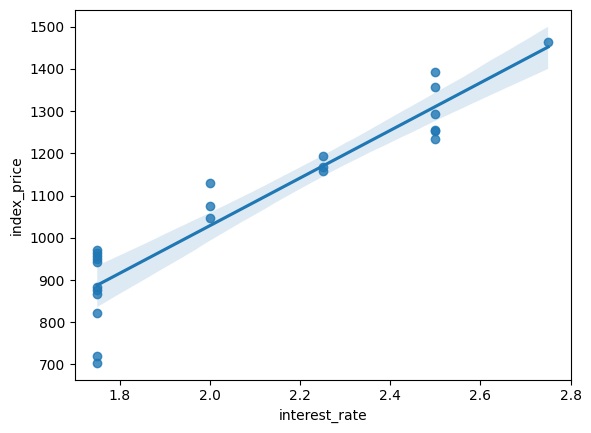

In [27]:
sns.regplot(x='interest_rate', y='index_price', data=df_index)

In [28]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [29]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [30]:
from sklearn.metrics import r2_score
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.8640024299625206

In [32]:
print(1-(1-r2_score(y_test,y_pred))*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

0.8096034019475289


In [34]:
resiuals = y_test - y_pred
print(resiuals)

8     -33.130837
16    146.760282
0      63.580288
18     27.839833
11     82.774947
9       6.789612
13     44.998935
1      65.804277
Name: index_price, dtype: float64


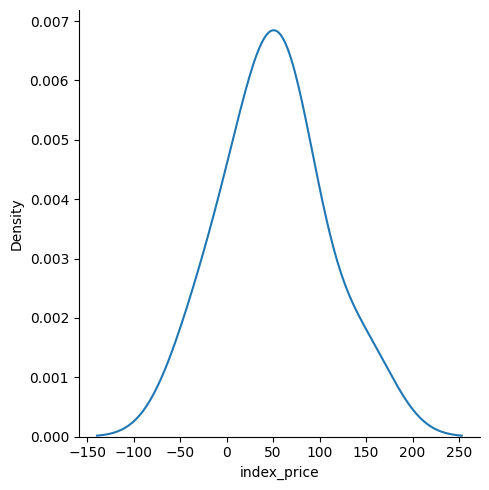

In [35]:
sns.displot(resiuals,kind='kde')

Text(0, 0.5, 'y_pred')

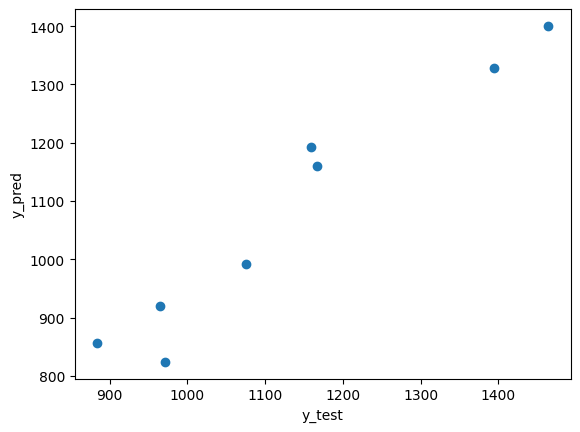

In [33]:
plt.scatter(y_test,y_pred)
plt.xlabel('y_test')
plt.ylabel('y_pred')

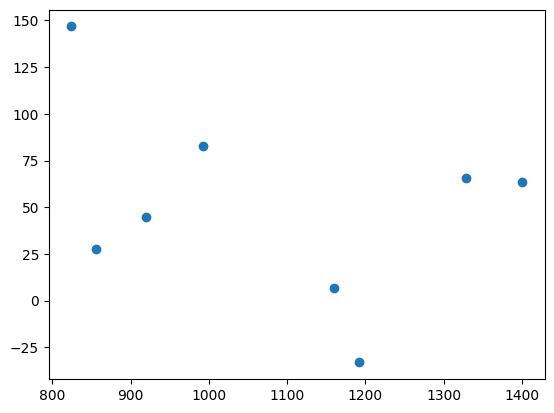

In [36]:
plt.scatter(y_pred,resiuals)

In [37]:
import statsmodels.api as sm

In [38]:
model =sm.OLS(y_train,X_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.033
Model:                            OLS   Adj. R-squared (uncentered):             -0.105
Method:                 Least Squares   F-statistic:                             0.2425
Date:                Wed, 23 Sep 2026   Prob (F-statistic):                       0.788
Time:                        11:58:00   Log-Likelihood:                         -133.85
No. Observations:                  16   AIC:                                      271.7
Df Residuals:                      14   BIC:                                      273.3
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            96.2869    682.952      0.141      0.890   -1368.500    1561.074
x2          -101.5702    682.952     -0.149      0.884   -1566.357    1363.216
==============================================================================
Omnibus:                        0.466   Durbin-Watson:                   0.008
Prob(Omnibus):                  0.792   Jarque-Bera (JB):                0.412
Skew:                          -0.327   Prob(JB):                        0.814
Kurtosis:                       2.563   Cond. No.                         4.70
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""